In [1]:
import os

os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")
os.environ["PROTOCOL_BUFFERS_PYTHON_IMPLEMENTATION"] = "python"
os.environ["PROTOCOL_BUFFERS_PYTHON_IMPLEMENTATION_VERSION"] = "3"
os.environ["PROTOCOL_BUFFERS_PYTHON_IMPLEMENTATION_DISABLE_C_DESCRIPTORS"] = "1"
os.environ.pop("PROTOCOL_BUFFERS_PYTHON_IMPLEMENTATION_C_DESCRIPTORS", None)
os.environ.setdefault("CUDA_VISIBLE_DEVICES", "-1")

# --- BUGFIX: Robust protobuf shim for TF import on this Kaggle image.
# Root cause: TF can call MessageFactory.GetPrototype during import; some protobuf builds omit it.
# Fix: Ensure GetPrototype exists on both the class and the module-level default factory instance,
# and do it BEFORE importing tensorflow/tf_keras.
try:
    from google.protobuf import message_factory as _message_factory  # noqa: E402

    def _ensure_getprototype_on_obj(obj):
        if obj is None:
            return
        if hasattr(obj, "GetPrototype"):
            return
        if hasattr(obj, "GetMessageClass"):

            def _GetPrototype(descriptor, _o=obj):
                return _o.GetMessageClass(descriptor)

            try:
                setattr(obj, "GetPrototype", _GetPrototype)
            except Exception:
                pass

    def _ensure_getprototype_on_cls(cls):
        if cls is None:
            return
        if hasattr(cls, "GetPrototype"):
            return
        if hasattr(cls, "GetMessageClass"):

            def _GetPrototype(self, descriptor):
                return self.GetMessageClass(descriptor)

            try:
                setattr(cls, "GetPrototype", _GetPrototype)
            except Exception:
                pass

    _ensure_getprototype_on_cls(getattr(_message_factory, "MessageFactory", None))

    # Patch likely module-level default factory handles across protobuf versions.
    for _name in (
        "_DEFAULT",
        "DEFAULT",
        "_default",
        "default_factory",
        "_default_factory",
    ):
        _ensure_getprototype_on_obj(getattr(_message_factory, _name, None))

    # Also patch the internal _DEFAULT_FACTORY if present (some versions use this).
    for _name in ("_DEFAULT_FACTORY", "DEFAULT_FACTORY"):
        _ensure_getprototype_on_obj(getattr(_message_factory, _name, None))

    # Ensure module _DEFAULT is a factory instance with GetPrototype.
    try:
        _inst = _message_factory.MessageFactory()
        _ensure_getprototype_on_obj(_inst)
        if (
            hasattr(_message_factory, "_DEFAULT")
            and getattr(_message_factory, "_DEFAULT") is None
        ):
            setattr(_message_factory, "_DEFAULT", _inst)
        else:
            _ensure_getprototype_on_obj(getattr(_message_factory, "_DEFAULT", None))
    except Exception:
        pass

except Exception as _e:
    print("Warning: protobuf patch skipped due to:", type(_e).__name__, _e)

import numpy as np
import pandas as pd
from datetime import datetime
import matplotlib.pyplot as plt
from sklearn import preprocessing
from sklearn.model_selection import train_test_split

import tensorflow as tf  # noqa: F401
import tf_keras as keras
from tf_keras.models import Sequential
from tf_keras.layers import Dense, Dropout, BatchNormalization, LSTM
from tf_keras.callbacks import EarlyStopping
from tf_keras import optimizers, regularizers
from tf_keras import backend

TRAIN_PATH = "/kaggle/input/new-york-city-taxi-fare-prediction/train.csv"
TEST_PATH = "/kaggle/input/new-york-city-taxi-fare-prediction/test.csv"
SUBMISSION_NAME = "submissiontry_water.csv"

BATCH_SIZE = 256
EPOCHS = 100
LEARNING_RATE = 0.001
DATASET_SIZE = 80000

np.random.seed(1)
tf.random.set_seed(1)



2026-01-19 12:50:12.980903: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1768827012.994863      11 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1768827012.999200      11 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

In [2]:
import urllib.request
from PIL import Image


def remove_datapoints_from_water(df):
    """
    Kaggle kernels typically have no internet; try to load mask, otherwise skip filter.
    """

    def lonlat_to_xy(longitude, latitude, dx, dy, BB):
        return (dx * (longitude - BB[0]) / (BB[1] - BB[0])).astype("int"), (
            dy - dy * (latitude - BB[2]) / (BB[3] - BB[2])
        ).astype("int")

    BB = (-74.5, -72.8, 40.5, 41.8)
    url = "https://aiblog.nl/download/nyc_mask-74.5_-72.8_40.5_41.8.png"

    try:
        with urllib.request.urlopen(url, timeout=10) as resp:
            nyc_mask_img = Image.open(resp)
            nyc_mask = np.array(nyc_mask_img)[:, :, 0] > 0.9
    except Exception as e:
        print(
            f"Warning: could not load NYC water mask ({type(e).__name__}: {e}). Skipping water removal."
        )
        return df

    pickup_x, pickup_y = lonlat_to_xy(
        df.pickup_longitude,
        df.pickup_latitude,
        nyc_mask.shape[1],
        nyc_mask.shape[0],
        BB,
    )
    dropoff_x, dropoff_y = lonlat_to_xy(
        df.dropoff_longitude,
        df.dropoff_latitude,
        nyc_mask.shape[1],
        nyc_mask.shape[0],
        BB,
    )

    pickup_x = np.clip(pickup_x, 0, nyc_mask.shape[1] - 1)
    dropoff_x = np.clip(dropoff_x, 0, nyc_mask.shape[1] - 1)
    pickup_y = np.clip(pickup_y, 0, nyc_mask.shape[0] - 1)
    dropoff_y = np.clip(dropoff_y, 0, nyc_mask.shape[0] - 1)

    idx = nyc_mask[pickup_y, pickup_x] & nyc_mask[dropoff_y, dropoff_x]
    return df[idx]


def clean(df):
    print(" Old size: %d" % len(df))
    df = df.dropna(how="any", axis="rows")
    print(" New size after dropna: %d" % len(df))

    df = df[
        (df["dropoff_longitude"] != df["pickup_longitude"])
        & (df["dropoff_latitude"] != df["pickup_latitude"])
    ]
    print(" New size after removing same long lat: %d" % len(df))

    df = df[
        (df["dropoff_longitude"] != 0)
        & (df["pickup_longitude"] != 0)
        & (df["dropoff_latitude"] != 0)
        & (df["pickup_latitude"] != 0)
    ]
    print(" New size after removing 0 long lat: %d" % len(df))

    MinMax = (-74.5, -72.8, 40.5, 41.8)
    df = df[
        (MinMax[0] <= df["pickup_longitude"]) & (df["pickup_longitude"] <= MinMax[1])
    ]
    df = df[
        (MinMax[0] <= df["dropoff_longitude"]) & (df["dropoff_longitude"] <= MinMax[1])
    ]
    df = df[(MinMax[2] <= df["pickup_latitude"]) & (df["pickup_latitude"] <= MinMax[3])]
    df = df[
        (MinMax[2] <= df["dropoff_latitude"]) & (df["dropoff_latitude"] <= MinMax[3])
    ]
    print(" New size after NYC lang lot: %d" % len(df))

    df = df[(df["pickup_latitude"] != 0)]
    df = df[(df["pickup_latitude"] != 0)]
    df = df[(df["dropoff_longitude"] != 0)]
    df = df[(df["dropoff_latitude"] != 0)]
    print(" New size after lang lot > 0: %d" % len(df))

    df = df[((df["pickup_latitude"] - df["dropoff_latitude"]).abs() > 0.001)]
    df = df[((df["pickup_longitude"] - df["dropoff_longitude"]).abs() > 0.001)]
    print(" New size after lang - lot > 0.001: %d" % len(df))

    print(" New size after only NYC: %d" % len(df))

    df = df[(0 < df["fare_amount"]) & (df["fare_amount"] <= 50)]
    print(" New size after removing outliers: %d" % len(df))

    df = df[(df["passenger_count"] > 0) & (df["passenger_count"] <= 6)]
    print(" New size after removing 6=>passenger_count > 0 : %d" % len(df))

    nyc_coord = (40.7141667, -74.0063889)
    fk_coord = (40.639722, -73.778889)
    ewr_coord = (40.6925, -74.168611)
    lga_coord = (40.77725, -73.872611)
    sol_coord = (40.6892, -74.0445)

    df = df[
        (nyc_coord[1] != df["pickup_longitude"])
        & (df["pickup_latitude"] != nyc_coord[0])
    ]
    df = df[
        (nyc_coord[1] != df["dropoff_longitude"])
        & (df["dropoff_latitude"] != nyc_coord[0])
    ]
    print(" New size after NY airport: %d" % len(df))

    df = df[
        (fk_coord[1] != df["pickup_longitude"]) & (df["pickup_latitude"] != fk_coord[0])
    ]
    df = df[
        (fk_coord[1] != df["dropoff_longitude"])
        & (df["dropoff_latitude"] != fk_coord[0])
    ]
    print(" New size after jfk airport: %d" % len(df))

    df = df[
        (ewr_coord[1] != df["pickup_longitude"])
        & (df["pickup_latitude"] != ewr_coord[0])
    ]
    df = df[
        (ewr_coord[1] != df["dropoff_longitude"])
        & (df["dropoff_latitude"] != ewr_coord[0])
    ]
    print(" New size after ewr airport: %d" % len(df))

    df = df[
        (lga_coord[1] != df["pickup_longitude"])
        & (df["pickup_latitude"] != lga_coord[0])
    ]
    df = df[
        (lga_coord[1] != df["dropoff_longitude"])
        & (df["dropoff_latitude"] != lga_coord[0])
    ]
    print(" New size after lgr airport: %d" % len(df))

    df = df[
        (sol_coord[1] != df["pickup_longitude"])
        & (df["pickup_latitude"] != sol_coord[0])
    ]
    df = df[
        (sol_coord[1] != df["dropoff_longitude"])
        & (df["dropoff_latitude"] != sol_coord[0])
    ]
    print(" New size after sol removed: %d" % len(df))

    print("Old size: %d" % len(df))
    df = remove_datapoints_from_water(df)
    print("New size: %d" % len(df))

    print(" New size: %d" % len(df))
    return df


def late_night_hour(hour):
    return ((hour <= 3) | (hour >= 23)).astype(np.int8)


def night_hour_weekday(hour, weekday):
    return (((hour >= 20) | (hour <= 6)) & (weekday < 5)).astype(np.int8)


def rush_hour_hour_weekday(hour, weekday):
    return (((hour <= 20) & (hour >= 16)) & (weekday < 5)).astype(np.int8)


def manhattan(pickup_lat, pickup_long, dropoff_lat, dropoff_long):
    return np.abs(dropoff_lat - pickup_lat) + np.abs(dropoff_long - pickup_long)


def add_time_features(df):
    dt = pd.to_datetime(df["pickup_datetime"], errors="coerce")
    df["year"] = dt.dt.year
    df["month"] = dt.dt.month
    df["day"] = dt.dt.day
    df["hour"] = dt.dt.hour
    df["weekday"] = dt.dt.weekday

    df["pickup_datetime"] = dt.astype(str)

    hour = df["hour"].fillna(0).astype(np.int16)
    weekday = df["weekday"].fillna(0).astype(np.int16)
    df["night"] = night_hour_weekday(hour, weekday)
    df["late_night"] = late_night_hour(hour)
    df["rush_hour"] = rush_hour_hour_weekday(hour, weekday)
    return df


def add_coordinate_features(df):
    lat1 = df["pickup_latitude"]
    lat2 = df["dropoff_latitude"]
    lon1 = df["pickup_longitude"]
    lon2 = df["dropoff_longitude"]
    df["latdiff"] = (lat1 - lat2).abs()
    df["londiff"] = (lon1 - lon2).abs()
    return df


def add_distances_features(df):
    lat1 = df["pickup_latitude"]
    lat2 = df["dropoff_latitude"]
    lon1 = df["pickup_longitude"]
    lon2 = df["dropoff_longitude"]
    df["manhattan"] = manhattan(lat1, lon1, lat2, lon2)
    df["distance"] = np.sqrt(
        np.abs(df["pickup_longitude"] - df["dropoff_longitude"]) ** 2
        + np.abs(df["pickup_latitude"] - df["dropoff_latitude"]) ** 2
    )
    return df


def distance(lat1, lon1, lat2, lon2):
    p = 0.017453292519943295
    a = (
        0.5
        - np.cos((lat2 - lat1) * p) / 2
        + np.cos(lat1 * p) * np.cos(lat2 * p) * (1 - np.cos((lon2 - lon1) * p)) / 2
    )
    return 0.6213712 * 12742 * np.arcsin(np.sqrt(a))


def distanceP(lat1, lon1, lat2, lon2):
    p = 0.017453292519943295
    a = (
        0.5
        - np.cos((lat2 - lat1) * p) / 2
        + np.cos(lat1 * p) * np.cos(lat2 * p) * (1 - np.cos((lon2 - lon1) * p)) / 2
    )
    return 0.6213712 * 12742 * np.arcsin(np.sqrt(a))


def add_haversine_feature(df):
    df["haversine"] = distance(
        df["pickup_latitude"].astype("float64"),
        df["pickup_longitude"].astype("float64"),
        df["dropoff_latitude"].astype("float64"),
        df["dropoff_longitude"].astype("float64"),
    ).astype("float32")
    return df


def output_submission(raw_test, prediction, id_column, prediction_column, file_name):
    prediction = np.asarray(prediction).reshape(-1)
    if len(prediction) != len(raw_test):
        raise ValueError(
            f"Prediction length {len(prediction)} != test rows {len(raw_test)}"
        )
    prediction = np.where(np.isfinite(prediction), prediction, 0.0).astype("float32")

    df = pd.DataFrame(
        {
            id_column: raw_test[id_column].astype(str).values,
            prediction_column: prediction,
        }
    )
    df[[id_column, prediction_column]].to_csv(file_name, index=False)
    print("Output complete:", file_name, "rows:", len(df))


def plot_loss_accuracy_rmse(history):
    plt.figure(figsize=(20, 10))
    plt.plot(history.history["loss"])
    plt.plot(history.history["val_loss"])
    plt.title("model loss")
    plt.ylabel("loss")
    plt.xlabel("epoch")
    plt.legend(["train", "test"], loc="upper right")
    plt.show()

    if "rmse_metric" in history.history:
        plt.figure(figsize=(20, 10))
        plt.plot(history.history["rmse_metric"])
        plt.plot(history.history["val_rmse_metric"])
        plt.title("Model rmse")
        plt.ylabel("rmse")
        plt.xlabel("epoch")
        plt.legend(["train", "test"], loc="upper right")
        plt.show()




In [3]:
datatypes = {
    "key": "str",
    "fare_amount": "float32",
    "pickup_datetime": "str",
    "pickup_longitude": "float32",
    "pickup_latitude": "float32",
    "dropoff_longitude": "float32",
    "dropoff_latitude": "float32",
    "passenger_count": "uint8",
}

trainKaggle = pd.read_csv(
    TRAIN_PATH,
    nrows=DATASET_SIZE,
    dtype=datatypes,
    usecols=[
        "fare_amount",
        "pickup_datetime",
        "pickup_longitude",
        "pickup_latitude",
        "dropoff_longitude",
        "dropoff_latitude",
        "passenger_count",
    ],
)

testKaggle = pd.read_csv(
    TEST_PATH,
    dtype={
        "key": "str",
        "pickup_datetime": "str",
        "pickup_longitude": "float32",
        "pickup_latitude": "float32",
        "dropoff_longitude": "float32",
        "dropoff_latitude": "float32",
        "passenger_count": "uint8",
    },
    usecols=[
        "key",
        "pickup_datetime",
        "pickup_longitude",
        "pickup_latitude",
        "dropoff_longitude",
        "dropoff_latitude",
        "passenger_count",
    ],
)

required_train_cols = {
    "fare_amount",
    "pickup_datetime",
    "pickup_longitude",
    "pickup_latitude",
    "dropoff_longitude",
    "dropoff_latitude",
    "passenger_count",
}
required_test_cols = {
    "key",
    "pickup_datetime",
    "pickup_longitude",
    "pickup_latitude",
    "dropoff_longitude",
    "dropoff_latitude",
    "passenger_count",
}
missing_train = required_train_cols - set(trainKaggle.columns)
missing_test = required_test_cols - set(testKaggle.columns)
if missing_train:
    raise ValueError(f"Missing columns in trainKaggle: {missing_train}")
if missing_test:
    raise ValueError(f"Missing columns in testKaggle: {missing_test}")



In [4]:
train_df, test_df = train_test_split(trainKaggle, test_size=0.50, random_state=1)
test_df = test_df[:10000]



In [5]:
print("testKaggle Size %d" % len(testKaggle))
print("train_df Size %d" % len(train_df))
print("test_df Size %d" % len(test_df))



testKaggle Size 9914
train_df Size 40000
test_df Size 10000


In [6]:
train_df.describe()



,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
count,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000
mean,11.363712,-72.486961,39.900848,-72.500725,39.913555,1.668275
std,9.739785,10.527108,6.262844,10.474602,6.224748,1.295907
min,-44.900002,-75.423851,-74.006889,-74.689827,-74.006378,0.000000
25%,6.000000,-73.992121,40.734905,-73.991249,40.734131,1.000000
50%,8.500000,-73.981789,40.752573,-73.979980,40.753237,1.000000
75%,12.500000,-73.967115,40.767056,-73.963272,40.768224,2.000000
max,180.000000,40.783470,43.183331,40.802437,43.415192,6.000000


In [7]:
test_df.describe()



,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,11.370206,-72.572372,39.962261,-72.563927,39.958992,1.668300
std,9.563587,10.160276,5.835522,10.186098,5.849215,1.298863
min,-2.500000,-74.229141,-73.979324,-74.227051,-73.986359,0.000000
25%,6.000000,-73.992228,40.734276,-73.991226,40.734427,1.000000
50%,8.500000,-73.982101,40.752495,-73.980183,40.753588,1.000000
75%,12.900000,-73.967705,40.767259,-73.964073,40.768030,2.000000
max,143.000000,40.761665,41.523216,40.851028,41.543217,6.000000


In [8]:
pass



In [9]:
print("train_df clean")
train_df = clean(train_df)
test_df = clean(test_df)



train_df clean
 Old size: 40000
 New size after dropna: 40000
 New size after removing same long lat: 38825
 New size after removing 0 long lat: 38754
 New size after NYC lang lot: 38702
 New size after lang lot > 0: 38702
 New size after lang - lot > 0.001: 36058
 New size after only NYC: 36058
 New size after removing outliers: 35611
 New size after removing 6=>passenger_count > 0 : 35472
 New size after NY airport: 35462
 New size after jfk airport: 35462
 New size after ewr airport: 35462
 New size after lgr airport: 35457
 New size after sol removed: 35457
Old size: 35457
New size: 35457
 New size: 35457
 Old size: 10000
 New size after dropna: 10000
 New size after removing same long lat: 9710
 New size after removing 0 long lat: 9691
 New size after NYC lang lot: 9683
 New size after lang lot > 0: 9683
 New size after lang - lot > 0.001: 9047
 New size after only NYC: 9047
 New size after removing outliers: 8952
 New size after removing 6=>passenger_count > 0 : 8918
 New size af

In [10]:
train_df.describe()



,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
count,35457.000000,35457.000000,35457.000000,35457.000000,35457.000000,35457.000000
mean,10.969131,-73.976402,40.751514,-73.974335,40.752102,1.677497
std,7.835883,0.034737,0.027133,0.034443,0.030796,1.296573
min,2.500000,-74.295540,40.511086,-74.302139,40.517769,1.000000
25%,6.100000,-73.992462,40.736927,-73.991386,40.736164,1.000000
50%,8.500000,-73.982132,40.753551,-73.980247,40.754292,1.000000
75%,12.500000,-73.968712,40.767761,-73.964821,40.768909,2.000000
max,50.000000,-73.137390,41.650002,-73.137390,41.366138,6.000000


In [11]:
print("train_df add_time_features")
train_df = add_time_features(train_df)
print("test_df add_time_features")
test_df = add_time_features(test_df)
print("testKaggle add_time_features")
testKaggle = add_time_features(testKaggle)



train_df add_time_features
test_df add_time_features
testKaggle add_time_features


In [12]:
train_df.describe()



,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,year,month,day,hour,weekday,night,late_night,rush_hour
count,35457.000000,35457.000000,35457.000000,35457.000000,35457.000000,35457.000000,35457.000000,35457.000000,35457.000000,35457.000000,35457.000000,35457.000000,35457.000000,35457.000000
mean,10.969131,-73.976402,40.751514,-73.974335,40.752102,1.677497,2011.741461,6.242491,15.700172,13.494627,3.050399,0.243337,0.157092,0.200045
std,7.835883,0.034737,0.027133,0.034443,0.030796,1.296573,1.871243,3.455057,8.659478,6.524442,1.952771,0.429103,0.363892,0.400039
min,2.500000,-74.295540,40.511086,-74.302139,40.517769,1.000000,2009.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,6.100000,-73.992462,40.736927,-73.991386,40.736164,1.000000,2010.000000,3.000000,8.000000,9.000000,1.000000,0.000000,0.000000,0.000000
50%,8.500000,-73.982132,40.753551,-73.980247,40.754292,1.000000,2012.000000,6.000000,16.000000,14.000000,3.000000,0.000000,0.000000,0.000000
75%,12.500000,-73.968712,40.767761,-73.964821,40.768909,2.000000,2013.000000,9.000000,23.000000,19.000000,5.000000,0.000000,0.000000,0.000000
max,50.000000,-73.137390,41.650002,-73.137390,41.366138,6.000000,2015.000000,12.000000,31.000000,23.000000,6.000000,1.000000,1.000000,1.000000


In [13]:
print("train_df add_coordinate_features")
train_df = add_coordinate_features(train_df)
print("test_df add_coordinate_features")
test_df = add_coordinate_features(test_df)
print("testKaggle add_coordinate_features")
testKaggle = add_coordinate_features(testKaggle)



train_df add_coordinate_features
test_df add_coordinate_features
testKaggle add_coordinate_features


In [14]:
train_df.describe()



,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,year,month,day,hour,weekday,night,late_night,rush_hour,latdiff,londiff
count,35457.000000,35457.000000,35457.000000,35457.000000,35457.000000,35457.000000,35457.000000,35457.000000,35457.000000,35457.000000,35457.000000,35457.000000,35457.000000,35457.000000,35457.000000,35457.000000
mean,10.969131,-73.976402,40.751514,-73.974335,40.752102,1.677497,2011.741461,6.242491,15.700172,13.494627,3.050399,0.243337,0.157092,0.200045,0.021689,0.022598
std,7.835883,0.034737,0.027133,0.034443,0.030796,1.296573,1.871243,3.455057,8.659478,6.524442,1.952771,0.429103,0.363892,0.400039,0.023181,0.031780
min,2.500000,-74.295540,40.511086,-74.302139,40.517769,1.000000,2009.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.001003,0.001007
25%,6.100000,-73.992462,40.736927,-73.991386,40.736164,1.000000,2010.000000,3.000000,8.000000,9.000000,1.000000,0.000000,0.000000,0.000000,0.007759,0.006973
50%,8.500000,-73.982132,40.753551,-73.980247,40.754292,1.000000,2012.000000,6.000000,16.000000,14.000000,3.000000,0.000000,0.000000,0.000000,0.014935,0.013474
75%,12.500000,-73.968712,40.767761,-73.964821,40.768909,2.000000,2013.000000,9.000000,23.000000,19.000000,5.000000,0.000000,0.000000,0.000000,0.027885,0.024879
max,50.000000,-73.137390,41.650002,-73.137390,41.366138,6.000000,2015.000000,12.000000,31.000000,23.000000,6.000000,1.000000,1.000000,1.000000,0.868980,0.873192


In [15]:
print("train_df add_distances_features")
train_df = add_distances_features(train_df)
print("test_df add_distances_features")
test_df = add_distances_features(test_df)
print("testKaggle add_distances_features")
testKaggle = add_distances_features(testKaggle)

print("train_df add_haversine_feature")
train_df = add_haversine_feature(train_df)
print("test_df add_haversine_feature")
test_df = add_haversine_feature(test_df)
print("testKaggle add_haversine_feature")
testKaggle = add_haversine_feature(testKaggle)

print("Done with Adding features")



train_df add_distances_features
test_df add_distances_features
testKaggle add_distances_features
train_df add_haversine_feature
test_df add_haversine_feature
testKaggle add_haversine_feature
Done with Adding features


In [16]:
train_df.describe()



,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,year,month,day,hour,weekday,night,late_night,rush_hour,latdiff,londiff,manhattan,distance,haversine
count,35457.000000,35457.000000,35457.000000,35457.000000,35457.000000,35457.000000,35457.000000,35457.000000,35457.000000,35457.000000,35457.000000,35457.000000,35457.000000,35457.000000,35457.000000,35457.000000,35457.000000,35457.000000,35457.000000
mean,10.969131,-73.976402,40.751514,-73.974335,40.752102,1.677497,2011.741461,6.242491,15.700172,13.494627,3.050399,0.243337,0.157092,0.200045,0.021689,0.022598,0.044287,0.034055,2.071856
std,7.835883,0.034737,0.027133,0.034443,0.030796,1.296573,1.871243,3.455057,8.659478,6.524442,1.952771,0.429103,0.363892,0.400039,0.023181,0.031780,0.048269,0.036995,2.164037
min,2.500000,-74.295540,40.511086,-74.302139,40.517769,1.000000,2009.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.001003,0.001007,0.002262,0.001610,0.095639
25%,6.100000,-73.992462,40.736927,-73.991386,40.736164,1.000000,2010.000000,3.000000,8.000000,9.000000,1.000000,0.000000,0.000000,0.000000,0.007759,0.006973,0.018051,0.013866,0.845630
50%,8.500000,-73.982132,40.753551,-73.980247,40.754292,1.000000,2012.000000,6.000000,16.000000,14.000000,3.000000,0.000000,0.000000,0.000000,0.014935,0.013474,0.029884,0.022998,1.410277
75%,12.500000,-73.968712,40.767761,-73.964821,40.768909,2.000000,2013.000000,9.000000,23.000000,19.000000,5.000000,0.000000,0.000000,0.000000,0.027885,0.024879,0.052486,0.039820,2.491506
max,50.000000,-73.137390,41.650002,-73.137390,41.366138,6.000000,2015.000000,12.000000,31.000000,23.000000,6.000000,1.000000,1.000000,1.000000,0.868980,0.873192,1.529724,1.092474,64.253288


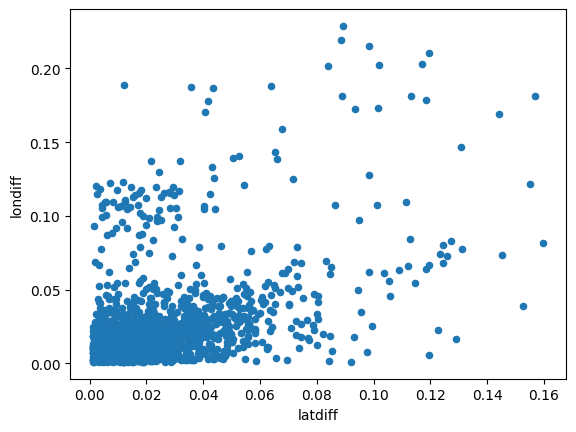

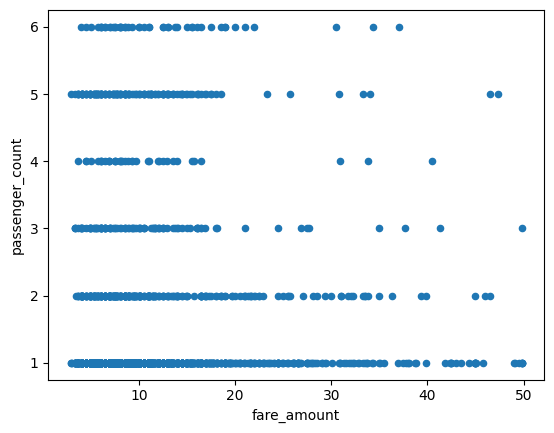

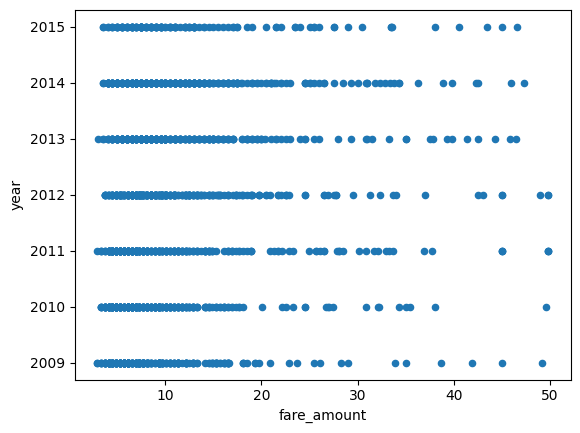

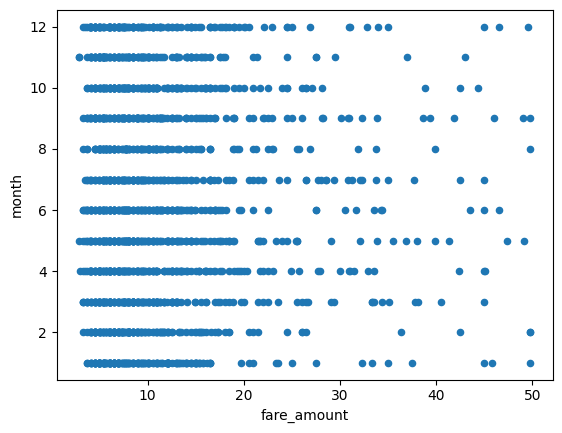

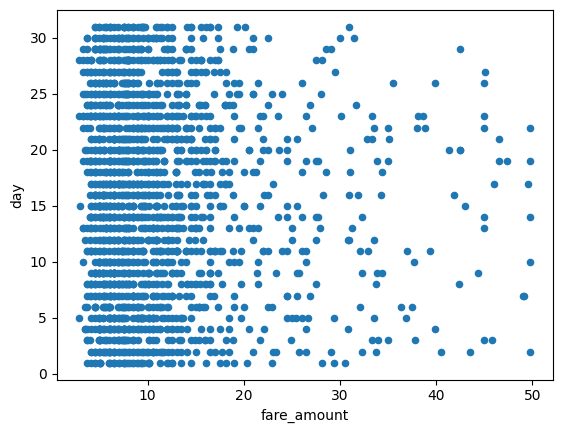

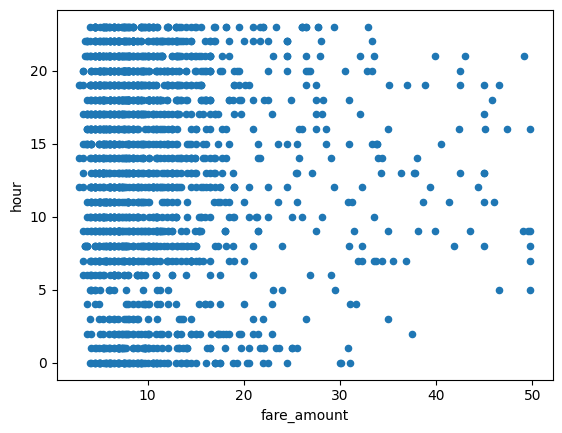

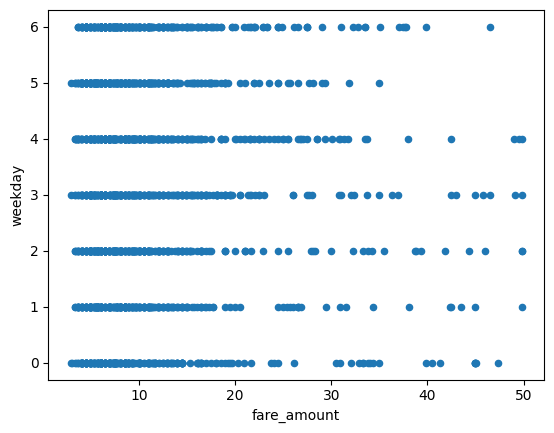

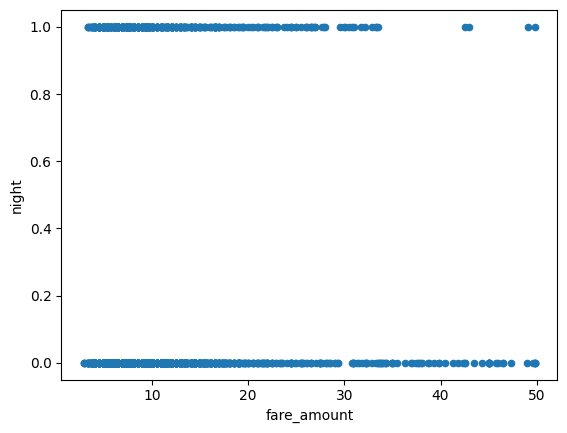

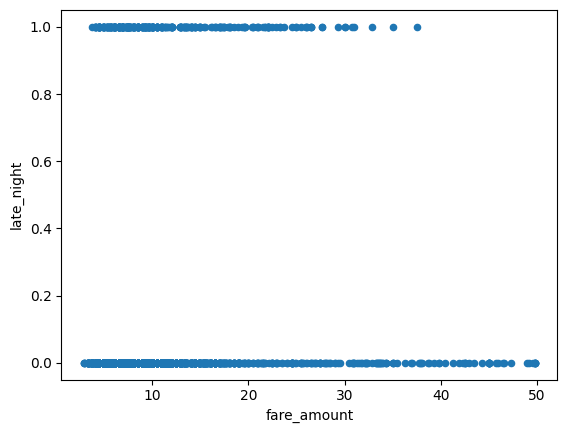

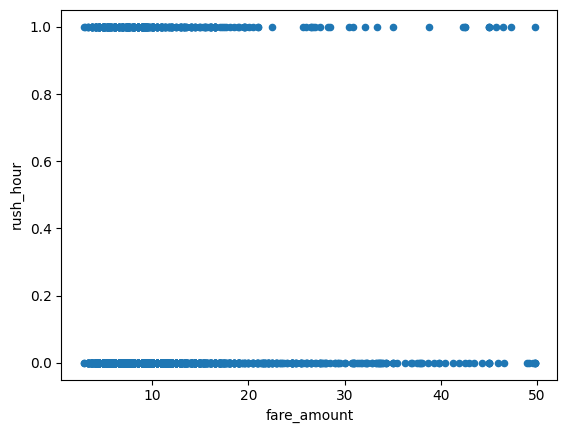

In [17]:
try:
    plot = train_df.iloc[:2000].plot.scatter("latdiff", "londiff")
    plot = train_df.iloc[:2000].plot.scatter("fare_amount", "passenger_count")
    plot = train_df.iloc[:2000].plot.scatter("fare_amount", "year")
    plot = train_df.iloc[:2000].plot.scatter("fare_amount", "month")
    plot = train_df.iloc[:2000].plot.scatter("fare_amount", "day")
    plot = train_df.iloc[:2000].plot.scatter("fare_amount", "hour")
    plot = train_df.iloc[:2000].plot.scatter("fare_amount", "weekday")
    plot = train_df.iloc[:2000].plot.scatter("fare_amount", "night")
    plot = train_df.iloc[:2000].plot.scatter("fare_amount", "late_night")
    plot = train_df.iloc[:2000].plot.scatter("fare_amount", "rush_hour")
except Exception as e:
    print("Plotting skipped due to:", e)



In [18]:
pass



In [19]:
dropped_columns = ["pickup_datetime"]  # keep passenger_count

train_df = train_df.drop(dropped_columns, axis=1)
test_df = test_df.drop(dropped_columns, axis=1)
testKaggle_clean = testKaggle.drop(dropped_columns + ["key"], axis=1)

print("Done with dropped_columns")



Done with dropped_columns


In [20]:
train_df.shape



(35457, 19)

In [21]:
train_df.describe()



,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,year,month,day,hour,weekday,night,late_night,rush_hour,latdiff,londiff,manhattan,distance,haversine
count,35457.000000,35457.000000,35457.000000,35457.000000,35457.000000,35457.000000,35457.000000,35457.000000,35457.000000,35457.000000,35457.000000,35457.000000,35457.000000,35457.000000,35457.000000,35457.000000,35457.000000,35457.000000,35457.000000
mean,10.969131,-73.976402,40.751514,-73.974335,40.752102,1.677497,2011.741461,6.242491,15.700172,13.494627,3.050399,0.243337,0.157092,0.200045,0.021689,0.022598,0.044287,0.034055,2.071856
std,7.835883,0.034737,0.027133,0.034443,0.030796,1.296573,1.871243,3.455057,8.659478,6.524442,1.952771,0.429103,0.363892,0.400039,0.023181,0.031780,0.048269,0.036995,2.164037
min,2.500000,-74.295540,40.511086,-74.302139,40.517769,1.000000,2009.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.001003,0.001007,0.002262,0.001610,0.095639
25%,6.100000,-73.992462,40.736927,-73.991386,40.736164,1.000000,2010.000000,3.000000,8.000000,9.000000,1.000000,0.000000,0.000000,0.000000,0.007759,0.006973,0.018051,0.013866,0.845630
50%,8.500000,-73.982132,40.753551,-73.980247,40.754292,1.000000,2012.000000,6.000000,16.000000,14.000000,3.000000,0.000000,0.000000,0.000000,0.014935,0.013474,0.029884,0.022998,1.410277
75%,12.500000,-73.968712,40.767761,-73.964821,40.768909,2.000000,2013.000000,9.000000,23.000000,19.000000,5.000000,0.000000,0.000000,0.000000,0.027885,0.024879,0.052486,0.039820,2.491506
max,50.000000,-73.137390,41.650002,-73.137390,41.366138,6.000000,2015.000000,12.000000,31.000000,23.000000,6.000000,1.000000,1.000000,1.000000,0.868980,0.873192,1.529724,1.092474,64.253288


In [22]:
test_df.describe()



,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,year,month,day,hour,weekday,night,late_night,rush_hour,latdiff,londiff,manhattan,distance,haversine
count,8914.000000,8914.000000,8914.000000,8914.000000,8914.000000,8914.000000,8914.000000,8914.000000,8914.000000,8914.000000,8914.00000,8914.00000,8914.000000,8914.000000,8914.000000,8914.000000,8914.000000,8914.000000,8914.000000
mean,11.019958,-73.976662,40.751408,-73.975113,40.752018,1.676913,2011.685551,6.338008,15.711016,13.445816,3.01133,0.24871,0.160983,0.201369,0.022081,0.022577,0.044658,0.034391,2.096644
std,7.840948,0.033978,0.028726,0.030701,0.031540,1.302782,1.865607,3.440028,8.709349,6.565418,1.95661,0.43229,0.367536,0.401045,0.023185,0.032184,0.048614,0.037254,2.174786
min,2.500000,-74.229141,40.514938,-74.227051,40.505650,1.000000,2009.000000,1.000000,1.000000,0.000000,0.00000,0.00000,0.000000,0.000000,0.001003,0.001007,0.002369,0.001679,0.104919
25%,6.100000,-73.992584,40.736270,-73.991438,40.736264,1.000000,2010.000000,3.000000,8.000000,9.000000,1.00000,0.00000,0.000000,0.000000,0.007891,0.006861,0.017964,0.013807,0.848486
50%,8.500000,-73.982368,40.753208,-73.980427,40.754601,1.000000,2012.000000,6.000000,16.000000,14.000000,3.00000,0.00000,0.000000,0.000000,0.015406,0.013680,0.030190,0.023241,1.437966
75%,12.900000,-73.969011,40.767757,-73.965706,40.768626,2.000000,2013.000000,9.000000,23.000000,19.000000,5.00000,0.00000,0.000000,0.000000,0.028457,0.024878,0.054023,0.041058,2.568396
max,50.000000,-73.137390,41.523216,-73.677856,41.543217,6.000000,2015.000000,12.000000,31.000000,23.000000,6.00000,1.00000,1.000000,1.000000,0.620819,0.859123,1.479942,1.059957,61.995472


In [23]:
train_df, validation_df = train_test_split(train_df, test_size=0.10, random_state=1)



In [24]:
train_df.describe()



,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,year,month,day,hour,weekday,night,late_night,rush_hour,latdiff,londiff,manhattan,distance,haversine
count,31911.000000,31911.000000,31911.000000,31911.000000,31911.000000,31911.000000,31911.000000,31911.000000,31911.000000,31911.000000,31911.000000,31911.000000,31911.000000,31911.000000,31911.000000,31911.000000,31911.000000,31911.000000,31911.000000
mean,10.974319,-73.976425,40.751564,-73.974243,40.752132,1.681426,2011.745793,6.233180,15.724578,13.494720,3.045188,0.244054,0.156623,0.201185,0.021703,0.022645,0.044348,0.034106,2.074588
std,7.859759,0.034598,0.027206,0.034437,0.030902,1.301223,1.871221,3.451467,8.663710,6.520663,1.953541,0.429532,0.363451,0.400892,0.023436,0.032059,0.048793,0.037385,2.187604
min,2.500000,-74.295540,40.511086,-74.302139,40.517769,1.000000,2009.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.001003,0.001007,0.002262,0.001610,0.095639
25%,6.100000,-73.992493,40.737015,-73.991386,40.736233,1.000000,2010.000000,3.000000,8.000000,9.000000,1.000000,0.000000,0.000000,0.000000,0.007790,0.006973,0.018063,0.013874,0.846920
50%,8.500000,-73.982140,40.753510,-73.980217,40.754314,1.000000,2012.000000,6.000000,16.000000,14.000000,3.000000,0.000000,0.000000,0.000000,0.014935,0.013458,0.029930,0.023015,1.411578
75%,12.500000,-73.968742,40.767801,-73.964699,40.768921,2.000000,2013.000000,9.000000,23.000000,19.000000,5.000000,0.000000,0.000000,0.000000,0.027809,0.024895,0.052479,0.039776,2.489328
max,50.000000,-73.137390,41.650002,-73.137390,41.366138,6.000000,2015.000000,12.000000,31.000000,23.000000,6.000000,1.000000,1.000000,1.000000,0.868980,0.873192,1.529724,1.092474,64.253288


In [25]:
validation_df.describe()



,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,year,month,day,hour,weekday,night,late_night,rush_hour,latdiff,londiff,manhattan,distance,haversine
count,3546.000000,3546.000000,3546.000000,3546.000000,3546.000000,3546.000000,3546.000000,3546.000000,3546.000000,3546.000000,3546.000000,3546.000000,3546.000000,3546.000000,3546.000000,3546.000000,3546.000000,3546.000000,3546.000000
mean,10.922457,-73.976135,40.751091,-73.975174,40.751842,1.642132,2011.702482,6.326283,15.480541,13.493796,3.097293,0.236887,0.161309,0.189791,0.021568,0.022174,0.043742,0.033600,2.047267
std,7.616565,0.032473,0.026245,0.029784,0.029716,1.253583,1.871252,3.486565,8.619412,6.559274,1.945479,0.425232,0.367867,0.392191,0.020747,0.029147,0.043268,0.033284,1.939217
min,2.900000,-74.102257,40.620579,-74.113213,40.582230,1.000000,2009.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.001019,0.001007,0.003204,0.002278,0.142055
25%,6.100000,-73.992262,40.735879,-73.991316,40.735786,1.000000,2010.000000,3.000000,8.000000,9.000000,1.000000,0.000000,0.000000,0.000000,0.007541,0.006905,0.017922,0.013832,0.830614
50%,8.500000,-73.982014,40.754015,-73.980583,40.754114,1.000000,2012.000000,6.000000,15.000000,14.000000,3.000000,0.000000,0.000000,0.000000,0.014898,0.013538,0.029486,0.022928,1.400946
75%,12.900000,-73.968506,40.767348,-73.965836,40.768805,2.000000,2013.000000,9.000000,23.000000,19.000000,5.000000,0.000000,0.000000,0.000000,0.028586,0.024817,0.052528,0.040160,2.521913
max,50.000000,-73.775810,40.875633,-73.743279,40.894493,6.000000,2015.000000,12.000000,31.000000,23.000000,6.000000,1.000000,1.000000,1.000000,0.208828,0.229561,0.357159,0.256147,16.384947


In [26]:
train_labels = train_df["fare_amount"].values
validation_labels = validation_df["fare_amount"].values
test_labels = test_df["fare_amount"].values

train_df = train_df.drop(["fare_amount"], axis=1)
validation_df = validation_df.drop(["fare_amount"], axis=1)
test_df = test_df.drop(["fare_amount"], axis=1)

print("Done with Labels")



Done with Labels


In [27]:
test_labels



array([ 4.9,  9.5, 12. , ...,  9.7,  5. ,  6.1], dtype=float32)

In [28]:
pass



In [29]:
pass



In [30]:
train_df.describe()



,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,year,month,day,hour,weekday,night,late_night,rush_hour,latdiff,londiff,manhattan,distance,haversine
count,31911.000000,31911.000000,31911.000000,31911.000000,31911.000000,31911.000000,31911.000000,31911.000000,31911.000000,31911.000000,31911.000000,31911.000000,31911.000000,31911.000000,31911.000000,31911.000000,31911.000000,31911.000000
mean,-73.976425,40.751564,-73.974243,40.752132,1.681426,2011.745793,6.233180,15.724578,13.494720,3.045188,0.244054,0.156623,0.201185,0.021703,0.022645,0.044348,0.034106,2.074588
std,0.034598,0.027206,0.034437,0.030902,1.301223,1.871221,3.451467,8.663710,6.520663,1.953541,0.429532,0.363451,0.400892,0.023436,0.032059,0.048793,0.037385,2.187604
min,-74.295540,40.511086,-74.302139,40.517769,1.000000,2009.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.001003,0.001007,0.002262,0.001610,0.095639
25%,-73.992493,40.737015,-73.991386,40.736233,1.000000,2010.000000,3.000000,8.000000,9.000000,1.000000,0.000000,0.000000,0.000000,0.007790,0.006973,0.018063,0.013874,0.846920
50%,-73.982140,40.753510,-73.980217,40.754314,1.000000,2012.000000,6.000000,16.000000,14.000000,3.000000,0.000000,0.000000,0.000000,0.014935,0.013458,0.029930,0.023015,1.411578
75%,-73.968742,40.767801,-73.964699,40.768921,2.000000,2013.000000,9.000000,23.000000,19.000000,5.000000,0.000000,0.000000,0.000000,0.027809,0.024895,0.052479,0.039776,2.489328
max,-73.137390,41.650002,-73.137390,41.366138,6.000000,2015.000000,12.000000,31.000000,23.000000,6.000000,1.000000,1.000000,1.000000,0.868980,0.873192,1.529724,1.092474,64.253288


In [31]:
validation_df.describe()



,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,year,month,day,hour,weekday,night,late_night,rush_hour,latdiff,londiff,manhattan,distance,haversine
count,3546.000000,3546.000000,3546.000000,3546.000000,3546.000000,3546.000000,3546.000000,3546.000000,3546.000000,3546.000000,3546.000000,3546.000000,3546.000000,3546.000000,3546.000000,3546.000000,3546.000000,3546.000000
mean,-73.976135,40.751091,-73.975174,40.751842,1.642132,2011.702482,6.326283,15.480541,13.493796,3.097293,0.236887,0.161309,0.189791,0.021568,0.022174,0.043742,0.033600,2.047267
std,0.032473,0.026245,0.029784,0.029716,1.253583,1.871252,3.486565,8.619412,6.559274,1.945479,0.425232,0.367867,0.392191,0.020747,0.029147,0.043268,0.033284,1.939217
min,-74.102257,40.620579,-74.113213,40.582230,1.000000,2009.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.001019,0.001007,0.003204,0.002278,0.142055
25%,-73.992262,40.735879,-73.991316,40.735786,1.000000,2010.000000,3.000000,8.000000,9.000000,1.000000,0.000000,0.000000,0.000000,0.007541,0.006905,0.017922,0.013832,0.830614
50%,-73.982014,40.754015,-73.980583,40.754114,1.000000,2012.000000,6.000000,15.000000,14.000000,3.000000,0.000000,0.000000,0.000000,0.014898,0.013538,0.029486,0.022928,1.400946
75%,-73.968506,40.767348,-73.965836,40.768805,2.000000,2013.000000,9.000000,23.000000,19.000000,5.000000,0.000000,0.000000,0.000000,0.028586,0.024817,0.052528,0.040160,2.521913
max,-73.775810,40.875633,-73.743279,40.894493,6.000000,2015.000000,12.000000,31.000000,23.000000,6.000000,1.000000,1.000000,1.000000,0.208828,0.229561,0.357159,0.256147,16.384947


In [32]:
test_df.describe()



,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,year,month,day,hour,weekday,night,late_night,rush_hour,latdiff,londiff,manhattan,distance,haversine
count,8914.000000,8914.000000,8914.000000,8914.000000,8914.000000,8914.000000,8914.000000,8914.000000,8914.000000,8914.00000,8914.00000,8914.000000,8914.000000,8914.000000,8914.000000,8914.000000,8914.000000,8914.000000
mean,-73.976662,40.751408,-73.975113,40.752018,1.676913,2011.685551,6.338008,15.711016,13.445816,3.01133,0.24871,0.160983,0.201369,0.022081,0.022577,0.044658,0.034391,2.096644
std,0.033978,0.028726,0.030701,0.031540,1.302782,1.865607,3.440028,8.709349,6.565418,1.95661,0.43229,0.367536,0.401045,0.023185,0.032184,0.048614,0.037254,2.174786
min,-74.229141,40.514938,-74.227051,40.505650,1.000000,2009.000000,1.000000,1.000000,0.000000,0.00000,0.00000,0.000000,0.000000,0.001003,0.001007,0.002369,0.001679,0.104919
25%,-73.992584,40.736270,-73.991438,40.736264,1.000000,2010.000000,3.000000,8.000000,9.000000,1.00000,0.00000,0.000000,0.000000,0.007891,0.006861,0.017964,0.013807,0.848486
50%,-73.982368,40.753208,-73.980427,40.754601,1.000000,2012.000000,6.000000,16.000000,14.000000,3.00000,0.00000,0.000000,0.000000,0.015406,0.013680,0.030190,0.023241,1.437966
75%,-73.969011,40.767757,-73.965706,40.768626,2.000000,2013.000000,9.000000,23.000000,19.000000,5.00000,0.00000,0.000000,0.000000,0.028457,0.024878,0.054023,0.041058,2.568396
max,-73.137390,41.523216,-73.677856,41.543217,6.000000,2015.000000,12.000000,31.000000,23.000000,6.00000,1.00000,1.000000,1.000000,0.620819,0.859123,1.479942,1.059957,61.995472


In [33]:
train_df = train_df.replace([np.inf, -np.inf], np.nan).fillna(0.0)
validation_df = validation_df.replace([np.inf, -np.inf], np.nan).fillna(0.0)
test_df = test_df.replace([np.inf, -np.inf], np.nan).fillna(0.0)
testKaggle_clean = testKaggle_clean.replace([np.inf, -np.inf], np.nan).fillna(0.0)

scaler = preprocessing.MinMaxScaler()
train_df_scaled = scaler.fit_transform(train_df)
validation_df_scaled = scaler.transform(validation_df)
test_scaled = scaler.transform(test_df)
testKaggle_scaled = scaler.transform(testKaggle_clean)



In [34]:
test_scaled




array([[0.25414852, 0.19389737, 0.26573697, ..., 0.00937028, 0.00927479,
        0.00960863],
       [0.27476762, 0.2136254 , 0.29063446, ..., 0.02036138, 0.02049467,
        0.02245597],
       [0.25621043, 0.1923064 , 0.27794663, ..., 0.03459411, 0.03542365,
        0.03941534],
       ...,
       [0.28909559, 0.22695606, 0.27606016, ..., 0.02048375, 0.02063999,
        0.02040933],
       [0.28150012, 0.24949759, 0.29409299, ..., 0.01381067, 0.01383438,
        0.01508357],
       [0.2632262 , 0.20261254, 0.27570644, ..., 0.01287414, 0.01283548,
        0.01388586]])

In [35]:
def rmse_metric(y_true, y_pred):
    return backend.sqrt(backend.mean(backend.square(y_pred - y_true), axis=-1))




In [36]:
model = Sequential()
model.add(
    Dense(
        256,
        activation="linear",
        input_dim=train_df_scaled.shape[1],
        activity_regularizer=regularizers.l1(0.01),
    )
)
model.add(BatchNormalization())
model.add(Dense(128, activation="relu"))
model.add(BatchNormalization())
model.add(Dense(64, activation="relu"))
model.add(BatchNormalization())
model.add(Dense(32, activation="relu"))
model.add(BatchNormalization())
model.add(Dense(8, activation="relu"))
model.add(BatchNormalization())
model.add(Dense(1, activation="relu"))

adam = optimizers.Adam(learning_rate=LEARNING_RATE)
model.compile(
    loss="mean_squared_error", optimizer=adam, metrics=["mae", rmse_metric, "mse"]
)

print("Dataset size: %s" % DATASET_SIZE)
print("Epochs: %s" % EPOCHS)
print("Learning rate: %s" % LEARNING_RATE)
print("Batch size: %s" % BATCH_SIZE)
print("Input dimension: %s" % train_df_scaled.shape[1])
print("Features used: %s" % list(train_df.columns))
model.summary()

history = model.fit(
    x=train_df_scaled,
    y=train_labels,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    verbose=1,
    validation_data=(validation_df_scaled, validation_labels),
    shuffle=True,
)



Dataset size: 80000
Epochs: 100
Learning rate: 0.001
Batch size: 256
Input dimension: 18
Features used: ['pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude', 'passenger_count', 'year', 'month', 'day', 'hour', 'weekday', 'night', 'late_night', 'rush_hour', 'latdiff', 'londiff', 'manhattan', 'distance', 'haversine']
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 256)               4864      
                                                                 
 batch_normalization (Batch  (None, 256)               1024      
 Normalization)                                                  
                                                                 
 dense_1 (Dense)             (None, 128)               32896     
                                                                 
 batch_normalization_1 (Bat  (None, 128)   

2026-01-19 12:50:22.859625: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


Epoch 1/100
125/125 [==============================] - 2s 4ms/step - loss: 130.6515 - mae: 9.2232 - rmse_metric: 9.2232 - mse: 130.4247 - val_loss: 120.3982 - val_mae: 8.1124 - val_rmse_metric: 8.1124 - val_mse: 120.2100
Epoch 2/100
125/125 [==============================] - 0s 2ms/step - loss: 101.1346 - mae: 7.9881 - rmse_metric: 7.9881 - mse: 100.9539 - val_loss: 55.8808 - val_mae: 4.5910 - val_rmse_metric: 4.5910 - val_mse: 55.7060
Epoch 3/100
125/125 [==============================] - 0s 2ms/step - loss: 62.3475 - mae: 6.5724 - rmse_metric: 6.5724 - mse: 62.1733 - val_loss: 24.8053 - val_mae: 3.3736 - val_rmse_metric: 3.3736 - val_mse: 24.6338
Epoch 4/100
125/125 [==============================] - 0s 2ms/step - loss: 37.5140 - mae: 4.9303 - rmse_metric: 4.9303 - mse: 37.3411 - val_loss: 18.3541 - val_mae: 2.8382 - val_rmse_metric: 2.8382 - val_mse: 18.1832
Epoch 5/100
125/125 [==============================] - 0s 2ms/step - loss: 25.3293 - mae: 3.7726 - rmse_metric: 3.7726 - mse: 

In [37]:
print(
    "Model visualization skipped (keras.utils.vis_utils not available in this environment)."
)



Model visualization skipped (keras.utils.vis_utils not available in this environment).


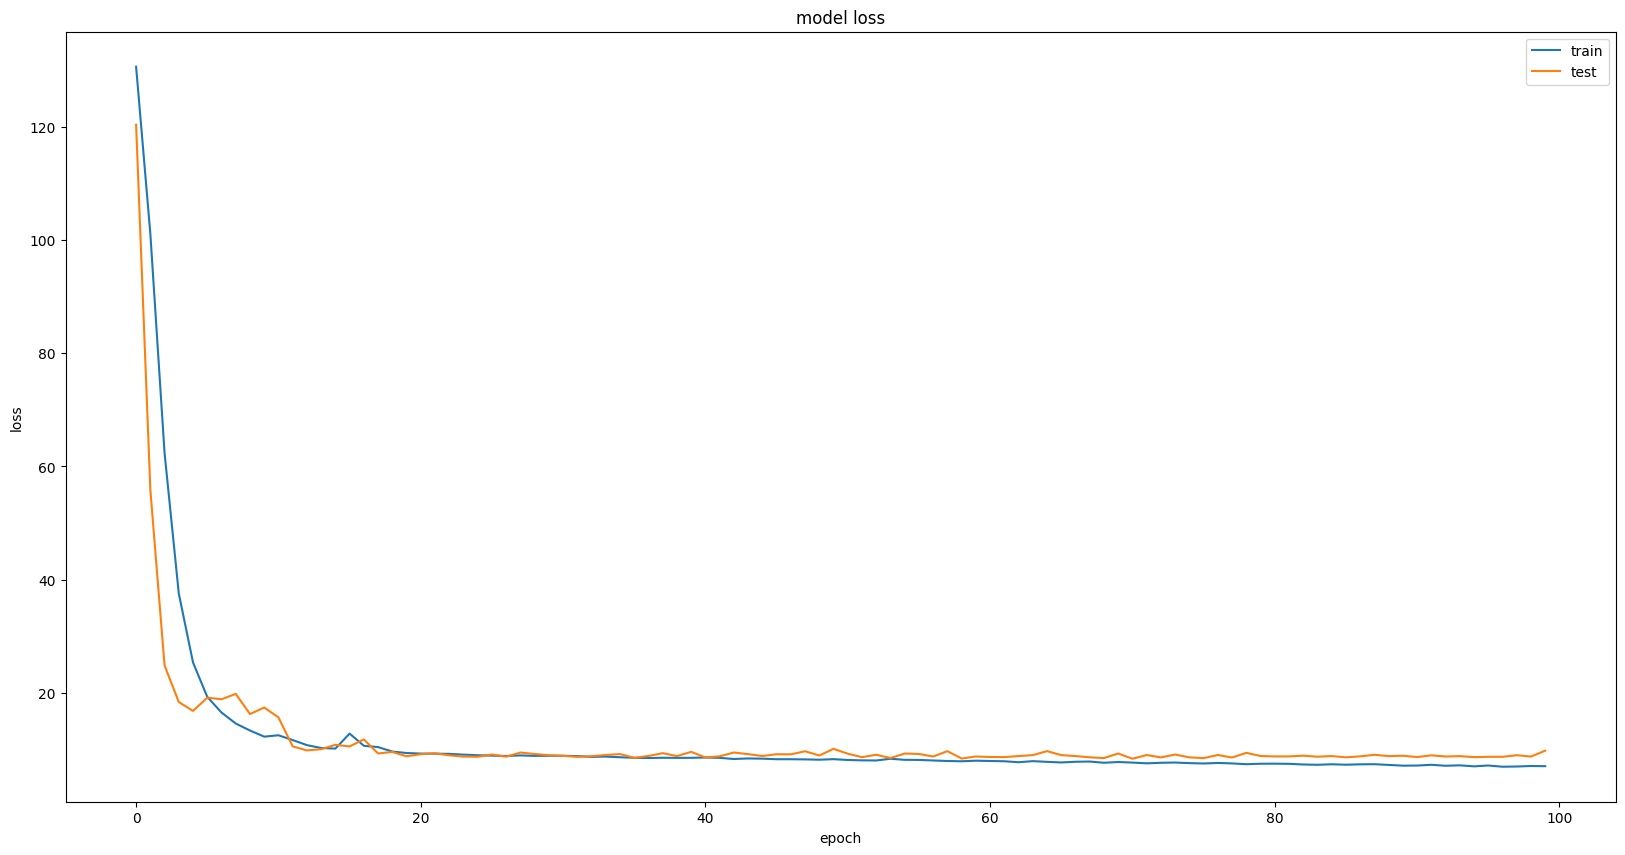

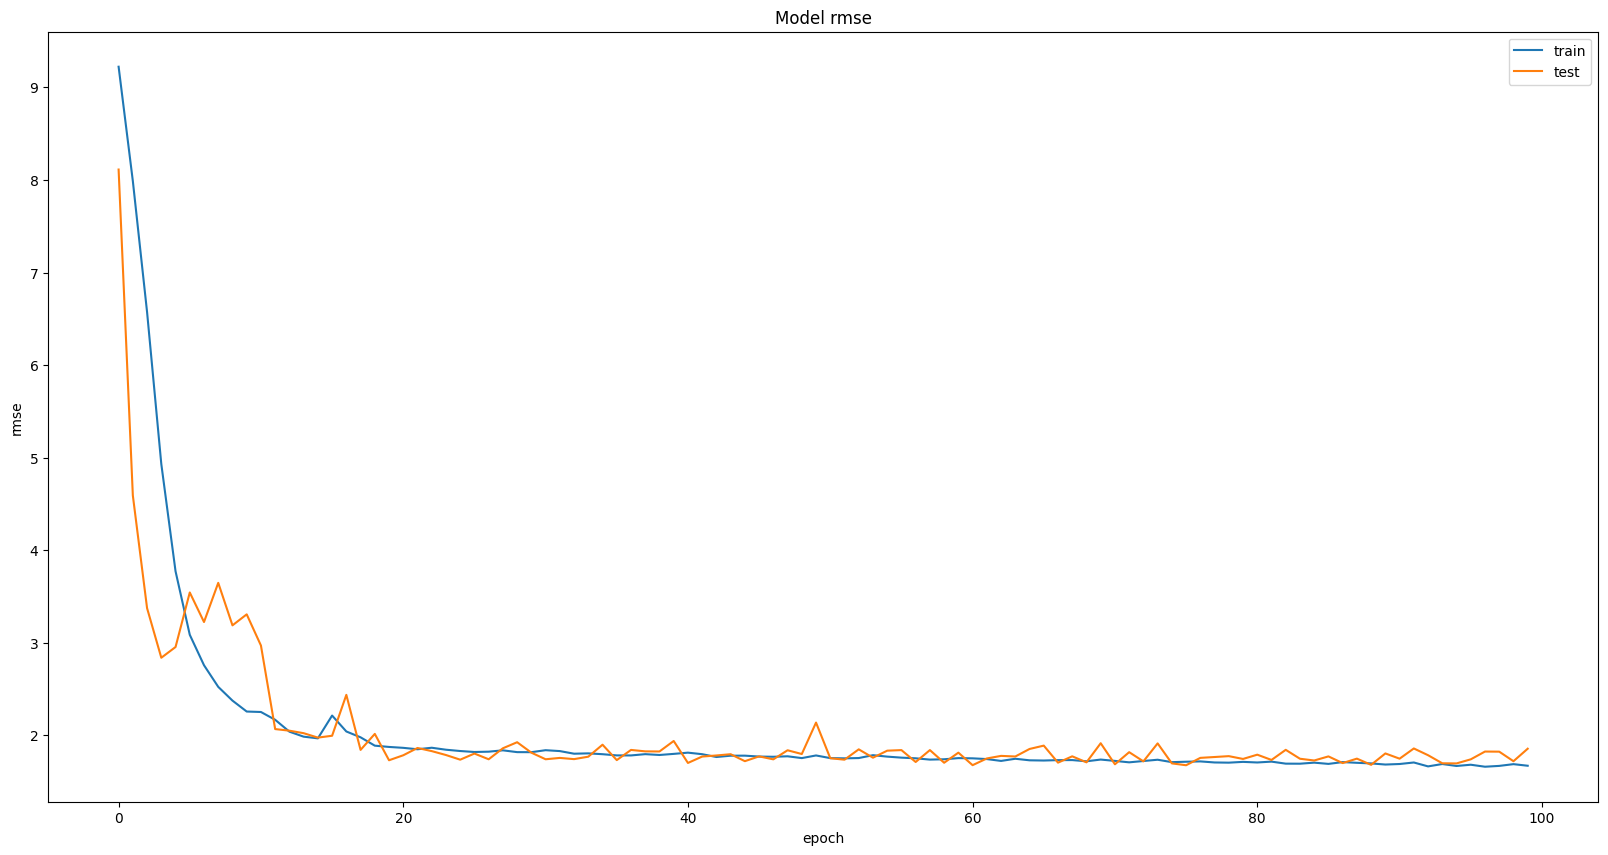

In [38]:
plot_loss_accuracy_rmse(history)



In [39]:
score = model.evaluate(train_df_scaled, train_labels, verbose=1)
print(score)
print("train mean_squared_error:", score[0])
print("train mae:", score[1])
print("train rmse:", score[2])
print("train mse:", score[3])



998/998 [==============================] - 1s 593us/step - loss: 7.7458 - mae: 1.7447 - rmse_metric: 1.7447 - mse: 7.6269
[7.745802402496338, 1.744659662246704, 1.744659662246704, 7.626925945281982]
train mean_squared_error: 7.745802402496338
train mae: 1.744659662246704
train rmse: 1.744659662246704
train mse: 7.626925945281982


In [40]:
score = model.evaluate(validation_df_scaled, validation_labels, verbose=1)
print(score)
print("Validation mean_squared_error:", score[0])
print("Validation mae:", score[1])
print("Validation rmse:", score[2])
print("Validation mse:", score[3])



111/111 [==============================] - 0s 602us/step - loss: 9.7529 - mae: 1.8553 - rmse_metric: 1.8553 - mse: 9.6353
[9.752883911132812, 1.8553414344787598, 1.8553414344787598, 9.635275840759277]
Validation mean_squared_error: 9.752883911132812
Validation mae: 1.8553414344787598
Validation rmse: 1.8553414344787598
Validation mse: 9.635275840759277


In [41]:
score = model.evaluate(test_scaled, test_labels, verbose=1)
print(score)
print("Test mean_squared_error:", score[0])
print("Test mae:", score[1])
print("Test rmse:", score[2])
print("Test mse:", score[3])



279/279 [==============================] - 0s 594us/step - loss: 10.1352 - mae: 1.8788 - rmse_metric: 1.8788 - mse: 10.0160
[10.135171890258789, 1.8787747621536255, 1.8787747621536255, 10.015958786010742]
Test mean_squared_error: 10.135171890258789
Test mae: 1.8787747621536255
Test rmse: 1.8787747621536255
Test mse: 10.015958786010742


111/111 [==============================] - 0s 543us/step


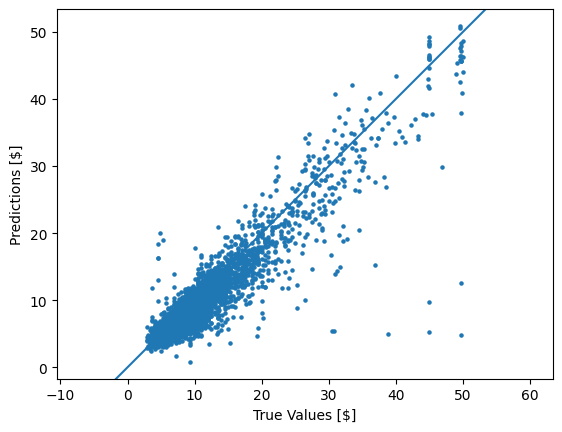

In [42]:
validation_predictions = model.predict(validation_df_scaled).flatten()

plt.scatter(validation_labels, validation_predictions, s=5)
plt.xlabel("True Values [$]")
plt.ylabel("Predictions [$]")
plt.axis("equal")
plt.xlim(plt.xlim())
plt.ylim(plt.ylim())
_ = plt.plot([-100, 100], [-100, 100])



279/279 [==============================] - 0s 506us/step


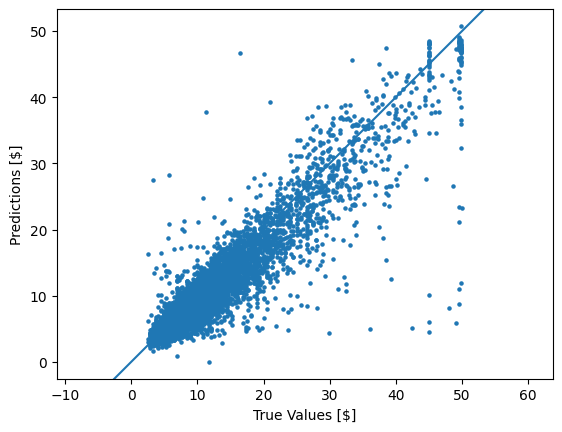

In [43]:
test_predictions = model.predict(test_scaled).flatten()

plt.scatter(test_labels, test_predictions, s=5)
plt.xlabel("True Values [$]")
plt.ylabel("Predictions [$]")
plt.axis("equal")
plt.xlim(plt.xlim())
plt.ylim(plt.ylim())
_ = plt.plot([-100, 100], [-100, 100])



In [44]:
predictionKaggle = model.predict(testKaggle_scaled, batch_size=128, verbose=1)




78/78 [==============================] - 0s 609us/step


In [45]:
def rmse(predictions, targets):
    return np.sqrt(((predictions - targets) ** 2).mean())




In [46]:
print(np.argmax(test_predictions))
print(test_predictions[np.argmax(test_predictions)])
print(test_labels[np.argmax(test_predictions)])
test_df.iloc[np.argmax(test_predictions)]



1008
50.760696
49.8


pickup_longitude      -73.781250
pickup_latitude        40.645134
dropoff_longitude     -73.993256
dropoff_latitude       40.752670
passenger_count         3.000000
year                 2011.000000
month                  12.000000
day                    18.000000
hour                   14.000000
weekday                 6.000000
night                   0.000000
late_night              0.000000
rush_hour               0.000000
latdiff                 0.107536
londiff                 0.212006
manhattan               0.319542
distance                0.237719
haversine              13.361763
Name: 21306, dtype: float64

In [47]:
print(np.argmin(test_predictions))
print(test_predictions[np.argmin(test_predictions)])
print(test_labels[np.argmin(test_predictions)])
test_df.iloc[np.argmin(test_predictions)]



4318
0.0
11.7


pickup_longitude      -73.631325
pickup_latitude        41.523216
dropoff_longitude     -73.677856
dropoff_latitude       41.543217
passenger_count         2.000000
year                 2010.000000
month                   3.000000
day                    29.000000
hour                   12.000000
weekday                 0.000000
night                   0.000000
late_night              0.000000
rush_hour               0.000000
latdiff                 0.020000
londiff                 0.046532
manhattan               0.066532
distance                0.050648
haversine               2.775201
Name: 42869, dtype: float64

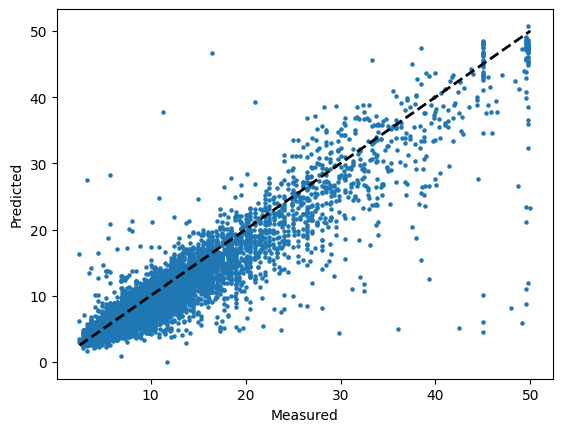

In [48]:
fig, ax = plt.subplots()
ax.scatter(test_labels, test_predictions, s=5)
ax.plot(
    [test_labels.min(), test_labels.max()],
    [test_labels.min(), test_labels.max()],
    "k--",
    lw=2,
)
ax.set_xlabel("Measured")
ax.set_ylabel("Predicted")
plt.show()



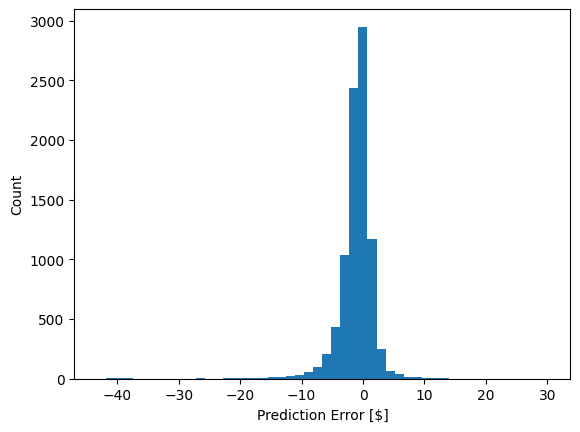

In [49]:
error = test_predictions - test_labels
plt.hist(error, bins=50)
plt.xlabel("Prediction Error [$]")
_ = plt.ylabel("Count")



In [50]:
from sklearn.linear_model import LinearRegression

val_pred = np.asarray(validation_predictions, dtype=np.float64).reshape(-1, 1)
val_y = np.asarray(validation_labels, dtype=np.float64).reshape(-1)

cal = LinearRegression()
cal.fit(val_pred, val_y)

predictionKaggle = np.asarray(predictionKaggle, dtype=np.float64).reshape(-1, 1)
predictionKaggle_cal = cal.predict(predictionKaggle).reshape(-1)

predictionKaggle_cal = np.where(
    np.isfinite(predictionKaggle_cal), predictionKaggle_cal, 0.0
).astype(np.float32)
predictionKaggle_cal = np.maximum(predictionKaggle_cal, 0.0)

# Safety guard: ensure alignment to Kaggle test rows even if something upstream changes shape.
if len(predictionKaggle_cal) != len(testKaggle):
    raise RuntimeError(
        f"Final prediction length {len(predictionKaggle_cal)} != testKaggle rows {len(testKaggle)}"
    )

output_submission(
    testKaggle, predictionKaggle_cal, "key", "fare_amount", SUBMISSION_NAME
)
print("Wrote submission to:", os.path.abspath(SUBMISSION_NAME))
print(
    "Calibration: fare ≈ %.6f * pred + %.6f"
    % (float(cal.coef_[0]), float(cal.intercept_))
)

Output complete: submissiontry_water.csv rows: 9914
Wrote submission to: /kaggle/working/submissiontry_water.csv
Calibration: fare ≈ 1.001479 * pred + 1.058209
